# Executive Sales Dashboard — Superstore Analysis
### Portfolio 1 · Data Cleaning + Exploratory Data Analysis

**Objective:** prepare a clean Superstore sales dataset and produce an analysis that a
CEO or Sales Director can use to monitor sales performance.

**Notebook workflow:**
1. Load the raw data
2. Data Cleaning (duplicates, missing values, date formats, currency formats, product-name consistency)
3. Exploratory Data Analysis (KPIs, monthly trend, region, category, top customers & products)
4. Export the clean dataset for the dashboard

**Dataset:** Sample Superstore (4 years of US retail orders — Furniture, Office Supplies, Technology).


## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df_raw = pd.read_csv("data/superstore_raw.csv")
print("Raw data shape:", df_raw.shape)
df_raw.head()

Raw data shape: (10800, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.00,0.00,41.91
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.00,0.00,219.58
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.00,0.00,6.87
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5.00,0.45,-383.03
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2.00,0.20,2.52


In [2]:
# Structure & data types overview
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  str    
 1   Order ID       10800 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       99

## 2. Data Cleaning

An initial inspection reveals several data-quality issues that must be fixed before analysis:
- **Duplicate rows**
- **Invalid rows** (junk records with no order data)
- **Date fields** stored as text
- **Currency / numeric formatting** (profit has long decimals)
- **Product-name consistency** (extra whitespace)


In [3]:
# --- Data-quality diagnosis ---
print("Full duplicate rows :", df_raw.duplicated().sum())
print("\nMissing values per column (non-zero only):")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

Full duplicate rows : 504

Missing values per column (non-zero only):
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64


In [4]:
# Inspect problem rows: records with a missing Order Date
df_raw[df_raw["Order Date"].isnull()].head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9994,Person,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9995,Anna Andreadi,West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,Chuck Magee,East,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> **Finding:** rows with a missing `Order Date` are actually **junk records** — the
> `Row ID` column holds a person's name and `Order ID` holds a region name, while every
> transactional column (Sales, Profit, etc.) is empty. These are not real orders and must
> be removed.

In [5]:
df = df_raw.copy()
n0 = len(df)

# 2.1 Remove duplicates
df = df.drop_duplicates()
n1 = len(df)
print(f"Remove duplicates : {n0:,} -> {n1:,}  (dropped {n0-n1:,})")

# 2.2 Remove invalid rows (no order data)
df = df[df["Order Date"].notnull()].copy()
n2 = len(df)
print(f"Remove invalid    : {n1:,} -> {n2:,}  (dropped {n1-n2:,})")

Remove duplicates : 10,800 -> 10,296  (dropped 504)
Remove invalid    : 10,296 -> 9,994  (dropped 302)


In [6]:
# 2.3 Date formatting: text -> datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  format="%m/%d/%Y")
print("Order date range:", df["Order Date"].min().date(), "to", df["Order Date"].max().date())

Order date range: 2015-01-03 to 2018-12-30


In [7]:
# 2.4 Currency / numeric formatting
df["Sales"]    = df["Sales"].round(2)
df["Profit"]   = df["Profit"].round(2)
df["Discount"] = df["Discount"].round(2)
df["Quantity"] = df["Quantity"].astype(int)

# 2.5 Name consistency (trim whitespace, collapse multiple spaces)
text_cols = ["Product Name", "Category", "Sub-Category", "Region", "Segment", "Customer Name"]
for c in text_cols:
    df[c] = df[c].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

# 2.6 Postal Code: Vermont is known to be missing in the source data -> fill & standardise to 5 digits
df.loc[(df["State"] == "Vermont") & (df["Postal Code"].isnull()), "Postal Code"] = 5401
df["Postal Code"] = df["Postal Code"].astype(int).astype(str).str.zfill(5)

print("Remaining missing values:", int(df.isnull().sum().sum()))

Remaining missing values: 0


In [8]:
# 2.7 Feature engineering for analysis
df["Order Month"]   = df["Order Date"].dt.to_period("M").astype(str)
df["Order Year"]    = df["Order Date"].dt.year
df["Profit Margin"] = np.where(df["Sales"] > 0, df["Profit"] / df["Sales"], 0)

df = df.sort_values("Order Date").reset_index(drop=True)
print("Final clean dataset:", df.shape)
df.head()

Final clean dataset: (9994, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Profit Margin
0,7981,CA-2015-103800,2015-01-03,2015-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55,2015-01,2015,0.34
1,740,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27,2015-01,2015,0.36
2,741,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77,2015-01,2015,-0.24
3,742,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49,2015-01,2015,-1.55
4,1760,CA-2015-141817,2015-01-05,2015-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88,2015-01,2015,0.25


**Cleaning summary:** `10,800 -> 10,296` (removed 504 duplicates) `-> 9,994`
(removed 302 invalid rows). The final dataset has **9,994 clean records** with no missing
values and correct data types.

## 3. Exploratory Data Analysis

### 3.1 Key Performance Indicators

In [9]:
total_sales  = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
margin       = total_profit / total_sales * 100
aov          = df.groupby("Order ID")["Sales"].sum().mean()

print(f"Total Sales        : ${total_sales:,.0f}")
print(f"Total Profit       : ${total_profit:,.0f}")
print(f"Total Orders       : {total_orders:,}")
print(f"Profit Margin      : {margin:.2f}%")
print(f"Avg Order Value    : ${aov:,.2f}")

Total Sales        : $2,297,201
Total Profit       : $286,397
Total Orders       : 5,009
Profit Margin      : 12.47%
Avg Order Value    : $458.61


### 3.2 Monthly Sales Trend

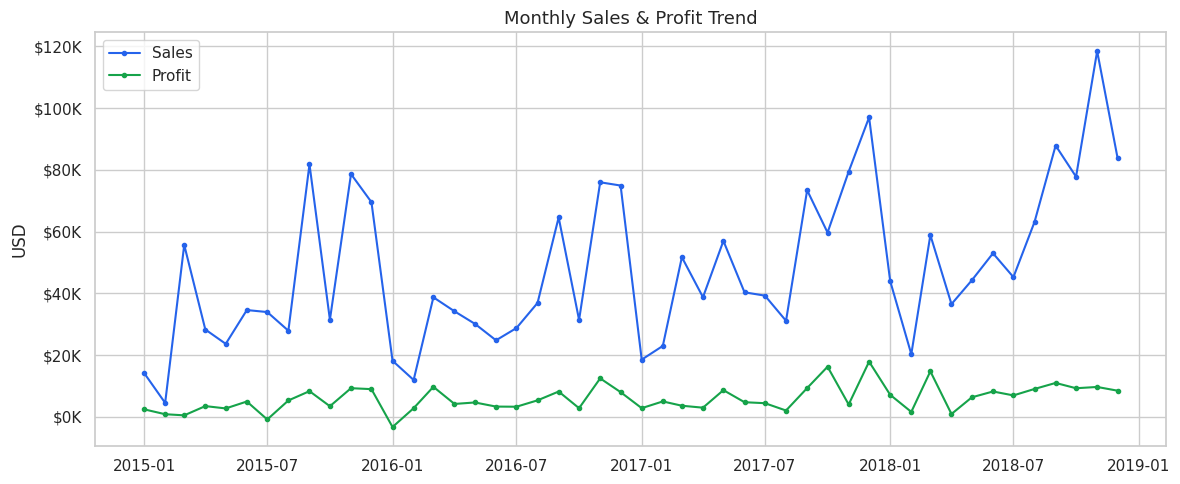

In [10]:
monthly = df.groupby("Order Month").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).reset_index()
monthly["Order Month"] = pd.to_datetime(monthly["Order Month"])

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(monthly["Order Month"], monthly["Sales"], marker="o", ms=3, label="Sales", color="#2563eb")
ax.plot(monthly["Order Month"], monthly["Profit"], marker="o", ms=3, label="Profit", color="#16a34a")
ax.set_title("Monthly Sales & Profit Trend")
ax.set_ylabel("USD"); ax.legend()
ax.yaxis.set_major_formatter(lambda x,_: f"${x/1000:.0f}K")
plt.tight_layout(); plt.show()

> Sales show a **steady year-over-year uptrend** with a **clear seasonal peak in Q4
> (Nov-Dec)** each year. Profit follows the same pattern but stays much thinner.

### 3.3 Sales & Profit by Region

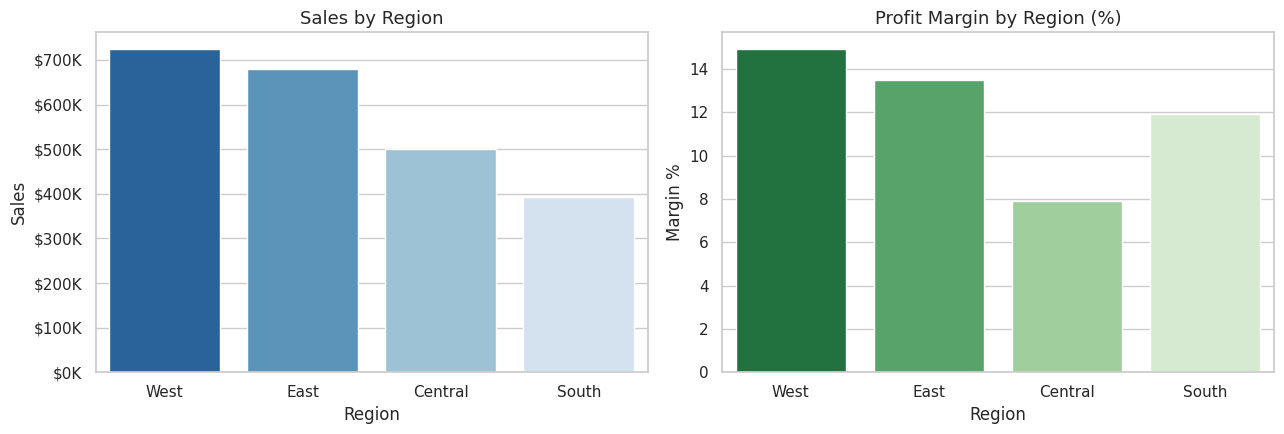

,Region,Sales,Profit,Margin %
3,West,"725,457.76","108,418.31",14.94
1,East,"678,781.30","91,522.50",13.48
0,Central,"501,239.76","39,706.24",7.92
2,South,"391,721.83","46,749.49",11.93


In [11]:
region = (df.groupby("Region")
            .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
            .reset_index())
region["Margin %"] = region["Profit"] / region["Sales"] * 100
region = region.sort_values("Sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.barplot(data=region, x="Region", y="Sales", ax=axes[0], palette="Blues_r", hue="Region", legend=False)
axes[0].set_title("Sales by Region"); axes[0].yaxis.set_major_formatter(lambda x,_: f"${x/1000:.0f}K")
sns.barplot(data=region, x="Region", y="Margin %", ax=axes[1], palette="Greens_r", hue="Region", legend=False)
axes[1].set_title("Profit Margin by Region (%)")
plt.tight_layout(); plt.show()
region

> **West & East** lead on sales. The flag to watch: **Central** has the lowest margin —
> a profitability problem, not a volume problem.

### 3.4 Sales & Profit by Category

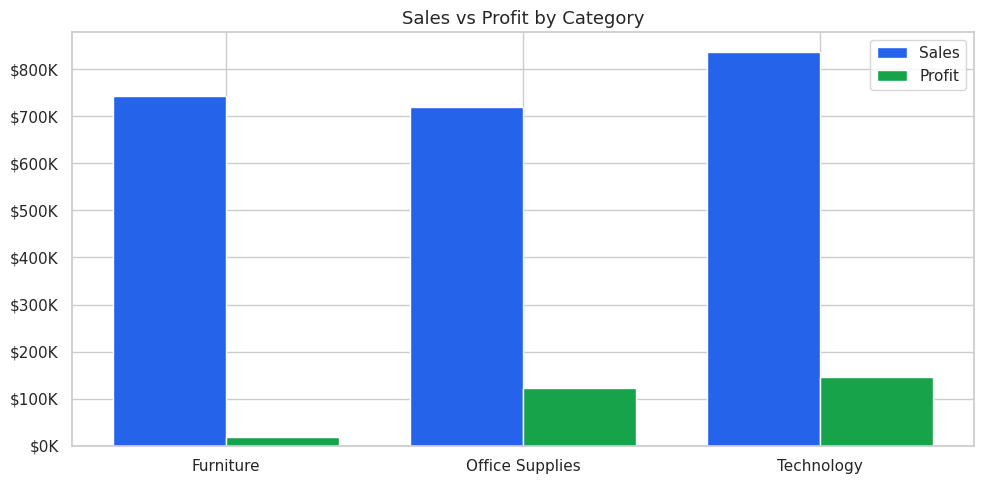

,Category,Sales,Profit,Margin %
0,Furniture,"741,999.73","18,451.10",2.49
1,Office Supplies,"719,046.90","122,490.00",17.04
2,Technology,"836,154.02","145,455.44",17.40


In [12]:
cat = (df.groupby("Category")
         .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
         .reset_index())
cat["Margin %"] = cat["Profit"] / cat["Sales"] * 100

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(cat)); w = 0.38
ax.bar(x-w/2, cat["Sales"],  w, label="Sales",  color="#2563eb")
ax.bar(x+w/2, cat["Profit"], w, label="Profit", color="#16a34a")
ax.set_xticks(x); ax.set_xticklabels(cat["Category"])
ax.set_title("Sales vs Profit by Category"); ax.legend()
ax.yaxis.set_major_formatter(lambda v,_: f"${v/1000:.0f}K")
plt.tight_layout(); plt.show()
cat

> **Technology** and **Office Supplies** are the profit engines. **Furniture** generates
> large sales but very thin profit — the prime candidate for investigation.

### 3.5 Discount vs Profit (by Sub-Category)

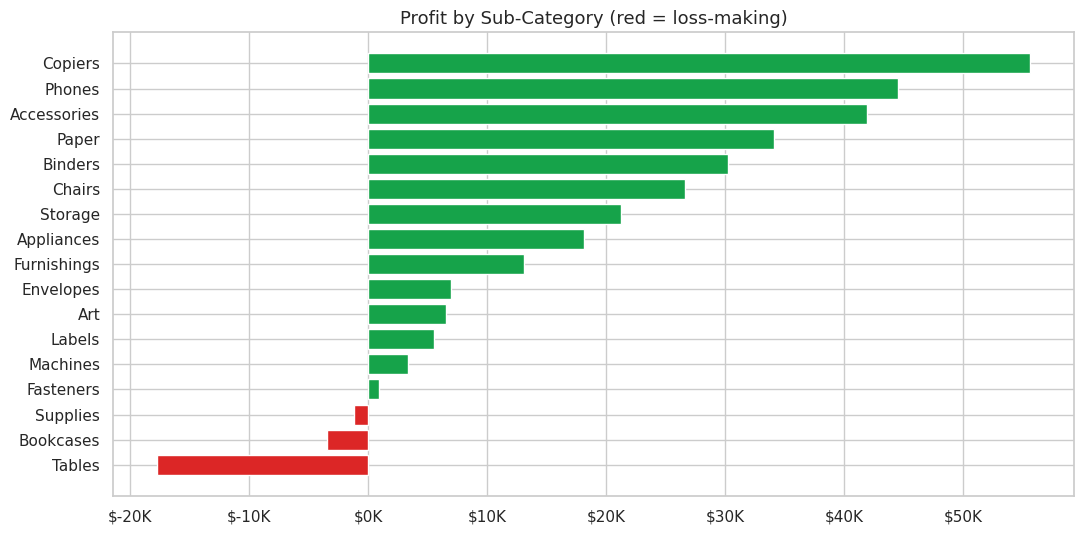

Most loss-making sub-categories:
Sub-Category      Sales     Profit  Discount  Margin %
      Tables 206,965.53 -17,725.57      0.26     -8.56
   Bookcases 114,879.98  -3,472.59      0.21     -3.02
    Supplies  46,673.52  -1,189.08      0.08     -2.55
   Fasteners   3,024.25     949.52      0.08     31.40
    Machines 189,238.60   3,384.72      0.31      1.79


In [13]:
sub = (df.groupby("Sub-Category")
         .agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Discount=("Discount","mean"))
         .reset_index())
sub["Margin %"] = sub["Profit"]/sub["Sales"]*100
order = sub.sort_values("Profit")

fig, ax = plt.subplots(figsize=(11,5.5))
ax.barh(order["Sub-Category"], order["Profit"],
        color=["#dc2626" if p<0 else "#16a34a" for p in order["Profit"]])
ax.set_title("Profit by Sub-Category (red = loss-making)")
ax.xaxis.set_major_formatter(lambda v,_: f"${v/1000:.0f}K")
plt.tight_layout(); plt.show()

print("Most loss-making sub-categories:")
print(order[["Sub-Category","Sales","Profit","Discount","Margin %"]].head(5).to_string(index=False))

> **Tables, Bookcases, and Supplies lose money** despite non-trivial sales. The pattern
> correlates strongly with **high discounts** — discounting erodes margin into negative territory.

Discount vs Profit correlation (transaction level): -0.219


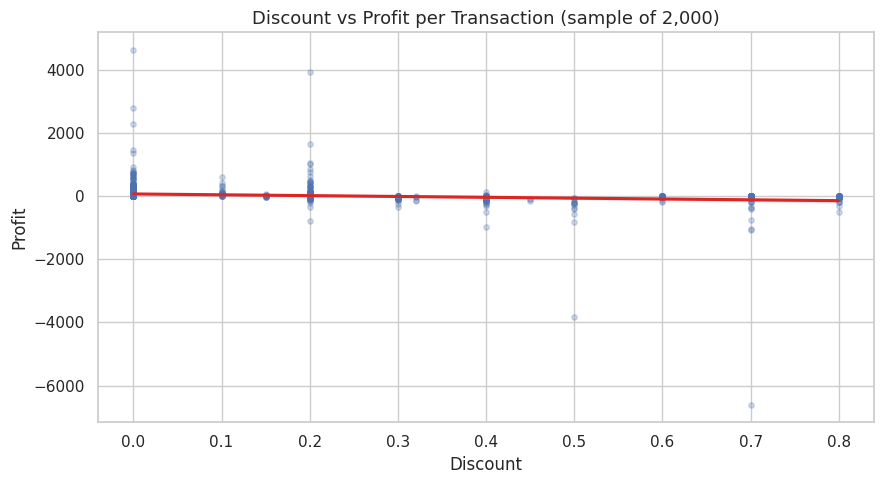

In [14]:
corr = df["Discount"].corr(df["Profit"])
print(f"Discount vs Profit correlation (transaction level): {corr:.3f}")
fig, ax = plt.subplots(figsize=(9,5))
sns.regplot(data=df.sample(2000, random_state=1), x="Discount", y="Profit",
            scatter_kws=dict(alpha=0.25, s=15), line_kws=dict(color="#dc2626"), ax=ax)
ax.set_title("Discount vs Profit per Transaction (sample of 2,000)")
plt.tight_layout(); plt.show()

### 3.6 Top 10 Customers & Products

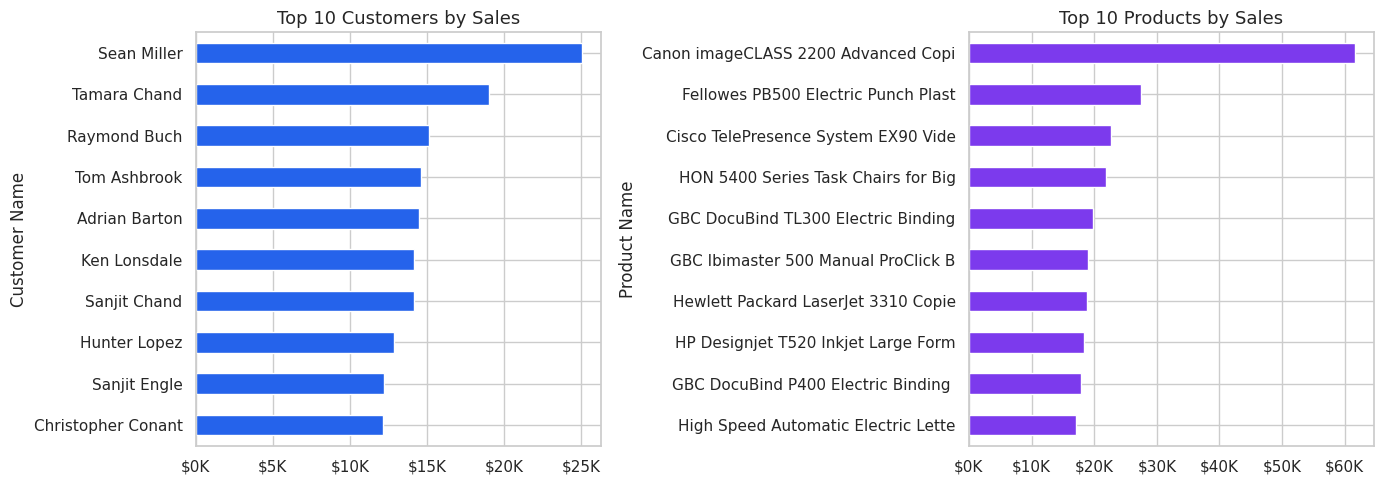

In [15]:
top_cust = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_prod = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1,2, figsize=(14,5))
top_cust.sort_values().plot.barh(ax=axes[0], color="#2563eb")
axes[0].set_title("Top 10 Customers by Sales"); axes[0].xaxis.set_major_formatter(lambda v,_:f"${v/1000:.0f}K")
top_prod.sort_values().plot.barh(ax=axes[1], color="#7c3aed")
axes[1].set_title("Top 10 Products by Sales"); axes[1].xaxis.set_major_formatter(lambda v,_:f"${v/1000:.0f}K")
axes[1].set_yticklabels([t.get_text()[:35] for t in axes[1].get_yticklabels()])
plt.tight_layout(); plt.show()

### 3.7 Sales by Customer Segment

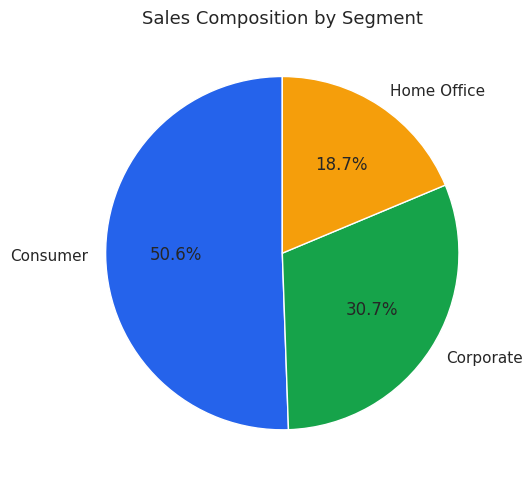

,Segment,Sales,Profit
0,Consumer,"1,161,401.12","134,118.64"
1,Corporate,"706,146.32","91,979.13"
2,Home Office,"429,653.21","60,298.77"


In [16]:
seg = df.groupby("Segment").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).reset_index()
fig, ax = plt.subplots(figsize=(7,5))
ax.pie(seg["Sales"], labels=seg["Segment"], autopct="%1.1f%%",
       colors=["#2563eb","#16a34a","#f59e0b"], startangle=90)
ax.set_title("Sales Composition by Segment"); plt.tight_layout(); plt.show()
seg

## 4. Export Clean Dataset

In [17]:
df.to_csv("data/superstore_clean.csv", index=False)
print("Saved: data/superstore_clean.csv", df.shape)

Saved: data/superstore_clean.csv (9994, 24)


## 5. Summary of Findings (Business Insights)

1. **Profitability - not volume - is the core issue.** Overall margin is only **12.5%**.
2. **Furniture** (especially **Tables & Bookcases**) is **loss-making** due to aggressive discounting.
3. **Central** is the lowest-margin region.
4. Sales are **seasonal** - peaking in Q4; an opportunity for inventory and campaign planning.
5. Revenue is **concentrated** in a small set of products and customers (a loyalty opportunity).

> Full recommendations and an action plan are provided in the **Executive Summary** PDF.
